# **Ejercicio 6: Modelo con otro algoritmo (Random Forest)**

El ejercicio pide un modelo con un algoritmo distinto a las redes neuronales y que se explique
la base de la seleccion. Se eligio Random Forest por dos razones.

La primera es que es el algoritmo con el que mayor familiaridad tenemos como grupo, de tal forma
que podemos concentrar el tiempo en interpretar los resultados y no en aprender el metodo.

La segunda es que su forma de funcionar encaja bien con el problema: un Random Forest entrena
varios arboles y cada uno trabaja sobre una muestra distinta del conjunto de datos, de tal forma
que cada arbol termina fijandose en aspectos diferentes de las imagenes y la decision final se
toma combinando todos. Bajo esta idea, esto puede resultar util para poder aprender de mejor
manera los diversos patrones que hay que identificar en las señas, ya que las letras no se
distinguen todas por lo mismo: unas se diferencian por la posicion del pulgar, otras por cuantos
dedos estan extendidos y otras por la orientacion de la mano.

El modelo consume el mismo tensor que las redes (`02_tensores.npz`), con la diferencia de que las
imagenes se aplanan de (64, 64, 1) a 4,096 caracteristicas. La evaluacion corre sobre
**validacion**; la particion de prueba se reserva para la comparacion final entre las tres
familias de modelos.

In [9]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

import config as cfg
import modelado as m

datos = m.cargar_tensores()
print("entrada aplanada:", m.aplanar(datos["x_train"]).shape)

[ok] entrada (64, 64, 1)
[cargado]  tensores -> train 12180, val 2610, test 2610
entrada aplanada: (12180, 4096)


## **Utilidades de visualizacion**

In [10]:
def graficar_matriz(resultado, titulo):
    mat = np.array(resultado["matriz_confusion"])
    plt.figure(figsize=(11, 9))
    sns.heatmap(mat, xticklabels=cfg.CLASES, yticklabels=cfg.CLASES,
                cmap="Blues", cbar=False, square=True)
    plt.title(f"{titulo}: matriz de confusion (validacion)")
    plt.xlabel("prediccion")
    plt.ylabel("real")
    plt.show()


def peores_confusiones(resultado, cuantas=10):
    mat = np.array(resultado["matriz_confusion"])
    np.fill_diagonal(mat, 0)
    pares = [(cfg.CLASES[i], cfg.CLASES[j], int(mat[i, j]))
             for i in range(cfg.NUM_CLASES) for j in range(cfg.NUM_CLASES) if mat[i, j] > 0]
    pares.sort(key=lambda p: -p[2])
    for real, pred, n in pares[:cuantas]:
        print(f"  {real:7s} predicha como {pred:7s} : {n}")


def graficar_importancia(bosque, titulo):
    imp = bosque.feature_importances_.reshape(cfg.RESOLUCION, cfg.RESOLUCION)
    plt.figure(figsize=(5, 5))
    plt.imshow(imp, cmap="hot")
    plt.colorbar(fraction=0.046)
    plt.title(f"{titulo}: importancia por pixel")
    plt.axis("off")
    plt.show()

## **Variante 1: 200 arboles**

Configuracion de partida. `max_features="sqrt"` significa que en cada corte el arbol considera
la raiz de 4,096, es decir 64 pixeles al azar, que es el valor por defecto para clasificacion.
Sin limite de profundidad, cada arbol crece hasta separar por completo su muestra.

In [11]:
rf1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features="sqrt",
    random_state=cfg.SEMILLA,
    n_jobs=-1,
)

t1 = m.entrenar_clasico(rf1, datos)
res1_train = m.evaluar(rf1, datos, "train")
res1 = m.evaluar(rf1, datos, "val")
reg1 = m.registrar("random_forest_v1", rf1, res1, t1,
                   notas="200 arboles, sin limite de profundidad, max_features=sqrt")

print(f"\nbrecha train-val: {res1_train['accuracy'] - res1['accuracy']:.4f}")

[info] entrenado en 9.7 s
[info] accuracy en train: 1.0000
[info] accuracy en val: 0.9644
[guardado] random_forest_v1.joblib
[guardado] random_forest_v1.json

brecha train-val: 0.0356


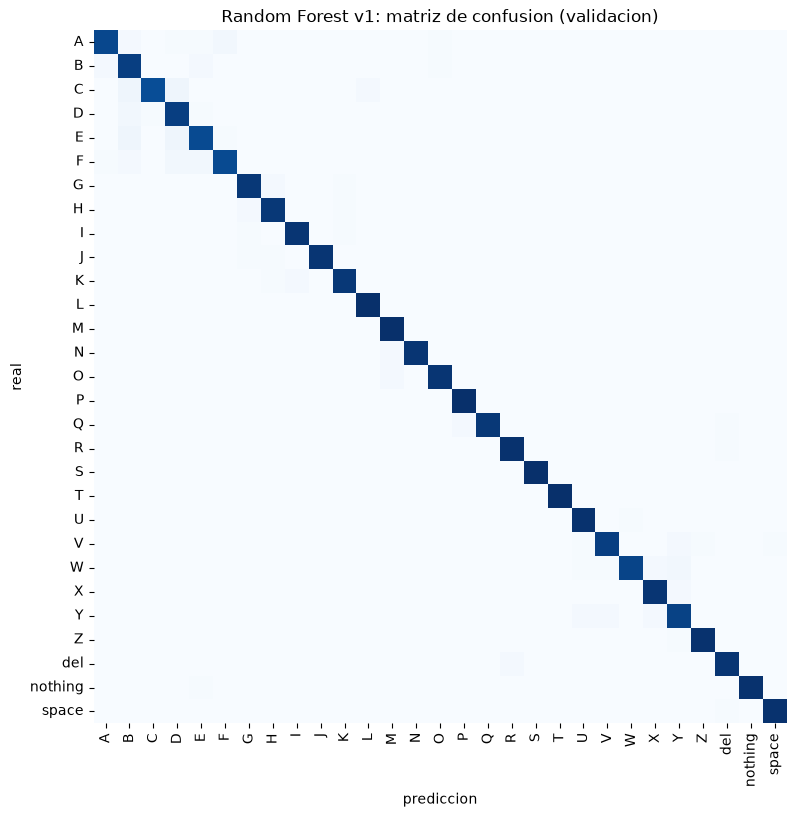

Confusiones mas frecuentes:
  C       predicha como B       : 4
  C       predicha como D       : 4
  E       predicha como B       : 4
  E       predicha como D       : 4
  A       predicha como F       : 3
  D       predicha como B       : 3
  F       predicha como D       : 3
  F       predicha como E       : 3
  W       predicha como Y       : 3
  A       predicha como B       : 2


In [12]:
graficar_matriz(res1, "Random Forest v1")
print("Confusiones mas frecuentes:")
peores_confusiones(res1)

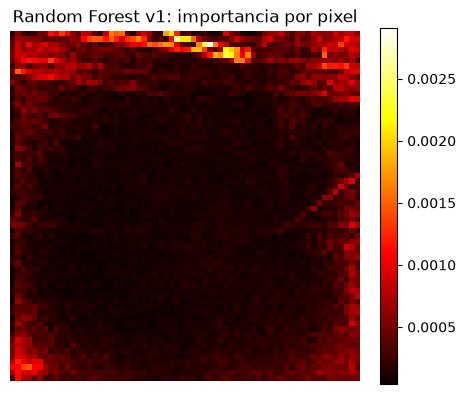

In [13]:
graficar_importancia(rf1, "Random Forest v1")

### **Discusion de la variante 1**

Al analizar la variante de 200 arboles se obtuvo un accuracy de 1.0000 sobre el conjunto de
entrenamiento. A primera vista esto parece alarmante, ya que acertar la totalidad de los datos
con los que el modelo aprendio suele ser la señal clasica de sobreajuste. No obstante, cabe
mencionar que en un Random Forest configurado con `max_depth=None` este resultado es el
comportamiento esperado por construccion, ya que cada arbol crece hasta que sus hojas quedan
puras, es decir hasta separar por completo la muestra que le toco; de tal forma que un accuracy
de 1 en entrenamiento no es por si solo evidencia de un problema, sino la consecuencia directa
de no haber limitado la profundidad.

Lo que si permite juzgar el sobreajuste es la brecha contra validacion. En este caso el accuracy
de validacion fue de 0.9644, de forma que la diferencia entre ambos es de apenas 0.0356.
Considero que ese numero es justamente la evidencia de que el modelo no se quedo unicamente
memorizando, ya que si solo hubiera memorizado el conjunto de entrenamiento el desempeño sobre
imagenes que nunca vio se habria desplomado, y no es lo que ocurre.

Dicho esto, si vale la pena matizar que tan exigente es esa validacion. Las imagenes del dataset
son bastante similares entre si, ya que provienen de las mismas sesiones de grabacion, con el
mismo fondo, la misma iluminacion y la misma mano; bajo ese escenario el conjunto de validacion
no representa un cambio real de condiciones frente al de entrenamiento, y es por esto que un
accuracy alto ahi no garantiza que el modelo se comporte igual con fotografias tomadas por
nosotros. En otras palabras, el modelo si generalizo, pero generalizo dentro de una distribucion
que de por si es facil.

Asimismo, el mapa de importancia por pixel deja la duda abierta en vez de cerrarla, ya que el
peso no se concentra sobre la zona central donde esta la mano sino sobre la franja superior y
los bordes del encuadre. Eso admite dos lecturas: puede ser que ahi sea donde aparecen o dejan
de aparecer las puntas de los dedos, lo cual seria una señal legitima, o puede ser que el bosque
se este apoyando en caracteristicas del fondo. No se puede resolver mirando unicamente ese
grafico, pero queda como una alerta a tener presente para la prueba con nuestras propias
fotografias.

## **Variante 2: 500 arboles**

Se mantiene todo igual y unicamente se sube la cantidad de arboles que votan, de 200 a 500, para
poder ver si el ensamble sigue ganando precision al agregar mas estimadores o si ya se estanco.

In [14]:
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    random_state=cfg.SEMILLA,
    n_jobs=-1,
)

t2 = m.entrenar_clasico(rf2, datos)
res2_train = m.evaluar(rf2, datos, "train")
res2 = m.evaluar(rf2, datos, "val")
reg2 = m.registrar("random_forest_v2", rf2, res2, t2,
                   notas="500 arboles, sin limite de profundidad, max_features=sqrt")

print(f"\nbrecha train-val: {res2_train['accuracy'] - res2['accuracy']:.4f}")

[info] entrenado en 53.3 s
[info] accuracy en train: 1.0000
[info] accuracy en val: 0.9655
[guardado] random_forest_v2.joblib
[guardado] random_forest_v2.json

brecha train-val: 0.0345


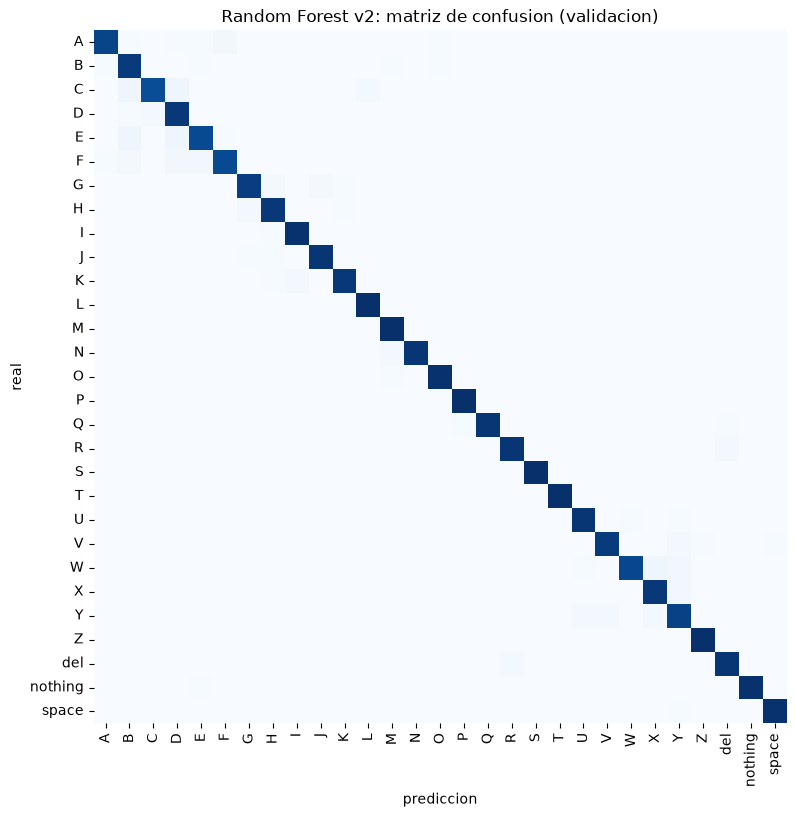

Confusiones mas frecuentes:
  C       predicha como B       : 4
  C       predicha como D       : 4
  E       predicha como B       : 4
  E       predicha como D       : 4
  W       predicha como X       : 4
  A       predicha como F       : 3
  F       predicha como D       : 3
  F       predicha como E       : 3
  W       predicha como Y       : 3
  X       predicha como Y       : 3


In [15]:
graficar_matriz(res2, "Random Forest v2")
print("Confusiones mas frecuentes:")
peores_confusiones(res2)

### **Discusion de la variante 2**

Al subir de 200 a 500 arboles el comportamiento se mantiene practicamente identico. El accuracy
en entrenamiento vuelve a ser de 1.0000, nuevamente por la misma razon de no haber limitado la
profundidad, mientras que en validacion se llega a 0.9655, es decir ligeramente por encima de la
variante anterior, con una brecha de 0.0345.

Cabe mencionar que triplicar la cantidad de arboles no cambio el diagnostico en ningun sentido:
la brecha se cerro apenas 0.0011 y el modelo sigue dependiendo de lo homogeneo que es el
dataset. Considero que esto es coherente con la forma en que funciona el ensamble, ya que
agregar mas arboles reduce la varianza del voto conjunto, pero no modifica el hecho de que cada
arbol individual siga creciendo hasta separar por completo su propia muestra. Bajo esta idea,
mas estimadores estabilizan la decision, no corrigen el sobreajuste de los arboles que la
componen.

## **Comparacion entre las variantes**

Solo sobre validacion. La comparacion contra las CNN y la red simple se hace al final del
laboratorio, en un notebook aparte.

In [16]:
tabla = pd.DataFrame([
    {"modelo": r["nombre"],
     "accuracy_val": round(r["accuracy"], 4),
     "tiempo_seg": r["tiempo_entrenamiento_seg"],
     "notas": r["notas"]}
    for r in (reg1, reg2)
]).sort_values("accuracy_val", ascending=False)

tabla

,modelo,accuracy_val,tiempo_seg,notas
1,random_forest_v2,0.9655,53.3,"500 arboles, sin limite de profundidad, max_fe..."
0,random_forest_v1,0.9644,9.7,"200 arboles, sin limite de profundidad, max_fe..."


### **Discusion y seleccion**

Al contrastar ambas variantes se observa que, a pesar de que las dos alcanzan un accuracy de 1
en entrenamiento, las dos tambien sostienen metricas altas y bastante equiparables en
validacion: 0.9644 con 200 arboles y 0.9655 con 500. La diferencia entre ambas es de apenas
0.0011.

Dicho esto, el costo si las separa con claridad. La variante de 200 arboles se entreno en 9.7
segundos, mientras que la de 500 tardo 53.3 segundos, es decir mas de cinco veces el tiempo para
ganar algo mas de una milesima de accuracy. Es por esto que no se justifica el incremento de
complejidad de 300 arboles adicionales, ya que el rendimiento resultante es practicamente el
mismo y el modelo queda considerablemente mas pesado sin ninguna ventaja practica.

Por lo tanto, la variante que se selecciona para la comparacion final contra las CNN y la red
neuronal simple es el Random Forest de 200 arboles. No obstante, cabe mencionar que la duda
sobre que tan real es esa generalizacion sigue abierta en ambas variantes, ya que el conjunto de
validacion comparte las mismas condiciones de captura que el de entrenamiento; la prueba con
nuestras propias fotografias es la que realmente va a poner a prueba si el modelo aprendio la
seña o el encuadre.